# 01_Setup



In [ ]:
# ============================================================
# Step 1. Google Drive 연결 및 프로젝트 경로 설정
# ============================================================

from google.colab import drive
from pathlib import Path
import os

drive.mount('/content/drive')

BASE_DIR = Path("/content/drive/MyDrive/datamining_project")

DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
MODEL_DIR = BASE_DIR / "models"

for p in [DATA_RAW, DATA_PROCESSED, RESULTS_DIR, FIGURES_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("DATA_RAW:", DATA_RAW)
print("FIGURES_DIR:", FIGURES_DIR)
print("MODEL_DIR:", MODEL_DIR)

print("\n[파일 존재 확인]")
print("train.csv:", (DATA_RAW / "train.csv").exists())
print("valid.csv:", (DATA_RAW / "valid.csv").exists())
print("test.csv :", (DATA_RAW / "test.csv").exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_DIR: /content/drive/MyDrive/datamining_project
DATA_RAW: /content/drive/MyDrive/datamining_project/data/raw
FIGURES_DIR: /content/drive/MyDrive/datamining_project/results/figures
MODEL_DIR: /content/drive/MyDrive/datamining_project/models

[파일 존재 확인]
train.csv: True
valid.csv: True
test.csv : True


# 02_Data_Load

In [ ]:
# ============================================================
# Step 1. Train / Valid / Test 데이터 로드
# ============================================================

import pandas as pd
import numpy as np

train_df = pd.read_csv(DATA_RAW / "train.csv")
valid_df = pd.read_csv(DATA_RAW / "valid.csv")
test_df  = pd.read_csv(DATA_RAW / "test.csv")

# 날짜 컬럼 변환
for df in [train_df, valid_df, test_df]:
    df["date"] = pd.to_datetime(df["date"])

print("[데이터 로드 완료]")
print("train:", train_df.shape)
print("valid:", valid_df.shape)
print("test :", test_df.shape)

print("\n[컬럼 목록]")
print(train_df.columns.tolist())

display(train_df.head())

[데이터 로드 완료]
train: (44268, 9)
valid: (5580, 9)
test : (5580, 9)

[컬럼 목록]
['date', 'adj_close', 'close', 'high', 'low', 'open', 'volume', 'ticker', 'group']


,date,adj_close,close,high,low,open,volume,ticker,group
0,2023-12-12,21594.337891,23300.0,23450.0,23050.0,23150.0,202001,000080.KS,Medium
1,2023-12-13,21594.337891,23300.0,23500.0,23100.0,23350.0,152072,000080.KS,Medium
2,2023-12-14,21640.677734,23350.0,23500.0,23200.0,23450.0,241168,000080.KS,Medium
3,2023-12-15,21408.978516,23100.0,23400.0,23100.0,23350.0,183231,000080.KS,Medium
4,2023-12-18,21501.660156,23200.0,23300.0,22950.0,23100.0,128306,000080.KS,Medium


In [ ]:
# ============================================================
# Step 2 Feature_engineering 데이터 로드
# ============================================================


print("[DATA_PROCESSED 경로]")
print(DATA_PROCESSED)

print("\n[processed 폴더 내부 파일 목록]")
for f in os.listdir(DATA_PROCESSED):
    print(f)



train_df = pd.read_csv(DATA_PROCESSED / "train_features.csv")
valid_df = pd.read_csv(DATA_PROCESSED / "valid_features.csv")
test_df  = pd.read_csv(DATA_PROCESSED / "test_features.csv")

# date 컬럼이 있으면 datetime으로 변환
for df in [train_df, valid_df, test_df]:
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])

print("[데이터 로드 완료]")
print("train:", train_df.shape)
print("valid:", valid_df.shape)
print("test :", test_df.shape)

print("\n[컬럼 목록]")
print(train_df.columns.tolist())

display(train_df.head())

[DATA_PROCESSED 경로]
/content/drive/MyDrive/datamining_project/data/processed

[processed 폴더 내부 파일 목록]
test_features.csv
train_features.csv
valid_features.csv
[데이터 로드 완료]
train: (42400, 17)
valid: (3807, 17)
test : (3701, 17)

[컬럼 목록]
['date', 'adj_close', 'close', 'high', 'low', 'open', 'volume', 'ticker', 'group', 'vol_chg_rate', 'volume_ma20_ratio', 'daily_return', 'volatility_5d', 'drawdown_after_peak_5d', 'upper_shadow_ratio', 'body_ratio', 'upper_shadow_streak_5d']


,date,adj_close,close,high,low,open,volume,ticker,group,vol_chg_rate,volume_ma20_ratio,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
0,2024-01-11,20674.576172,21400.0,22150.0,21200.0,22050.0,330021.0,000080.KS,Medium,1.539190,1.827646,-0.029478,0.012567,0.050998,0.105263,0.684211,2.0
1,2024-01-12,21061.017578,21800.0,21850.0,21400.0,21400.0,194748.0,000080.KS,Medium,-0.409892,1.080679,0.018692,0.017191,0.026786,0.111111,0.888889,1.0
2,2024-01-15,21350.847656,22100.0,22150.0,21750.0,21900.0,24583.0,000080.KS,Medium,-0.873770,0.141416,0.013761,0.018892,0.011186,0.125000,0.500000,0.0
3,2024-01-16,21012.712891,21750.0,22100.0,21700.0,22050.0,64781.0,000080.KS,Medium,1.635195,0.392576,-0.015837,0.020116,0.020270,0.125000,0.750000,0.0
4,2024-01-17,20626.271484,21350.0,21800.0,21300.0,21800.0,93005.0,000080.KS,Medium,0.435683,0.579456,-0.018391,0.021222,0.036117,0.000000,0.900000,0.0


# 03_Preprocessing

In [ ]:
# ============================================================
# Step 1. 전처리 상태 확인
# ============================================================

print("[Train]")
print("inf 개수 :", np.isinf(train_df.select_dtypes(include=np.number)).sum().sum())
print("NaN 개수 :", train_df.isna().sum().sum())
print("거래량 0 개수 :", (train_df["volume"] == 0).sum())

print("\n[Valid]")
print("inf 개수 :", np.isinf(valid_df.select_dtypes(include=np.number)).sum().sum())
print("NaN 개수 :", valid_df.isna().sum().sum())
print("거래량 0 개수 :", (valid_df["volume"] == 0).sum())

print("\n[Test]")
print("inf 개수 :", np.isinf(test_df.select_dtypes(include=np.number)).sum().sum())
print("NaN 개수 :", test_df.isna().sum().sum())
print("거래량 0 개수 :", (test_df["volume"] == 0).sum())

[Train]
inf 개수 : 0
NaN 개수 : 8
거래량 0 개수 : 0

[Valid]
inf 개수 : 0
NaN 개수 : 4
거래량 0 개수 : 0

[Test]
inf 개수 : 0
NaN 개수 : 2
거래량 0 개수 : 0


In [ ]:
# ============================================================
# Step 2. 전체 모델 공통 결측치 제거
# ============================================================

preprocessing_features = [
    "volume_ma20_ratio",
    "vol_chg_rate",
    "daily_return",
    "volatility_5d",
    "drawdown_after_peak_5d",
    "upper_shadow_ratio",
    "body_ratio",
    "upper_shadow_streak_5d"
]

train_df = (
    train_df
    .dropna(subset=preprocessing_features)
    .reset_index(drop=True)
)

valid_df = (
    valid_df
    .dropna(subset=preprocessing_features)
    .reset_index(drop=True)
)

test_df = (
    test_df
    .dropna(subset=preprocessing_features)
    .reset_index(drop=True)
)

print("===== 결측치 제거 후 =====")
print("train :", train_df.shape)
print("valid :", valid_df.shape)
print("test  :", test_df.shape)

print("\n===== 남은 NaN 개수 =====")
print("train :", train_df[preprocessing_features].isna().sum().sum())
print("valid :", valid_df[preprocessing_features].isna().sum().sum())
print("test  :", test_df[preprocessing_features].isna().sum().sum())

===== 결측치 제거 후 =====
train : (42396, 17)
valid : (3805, 17)
test  : (3700, 17)

===== 남은 NaN 개수 =====
train : 0
valid : 0
test  : 0


# 06_Main_Model

## Main_model version 1 : Isolation Forest + DBSCAN + KMeans


In [ ]:
# ============================================================
# Step1. Feature 정의
# ============================================================

main_cluster_features = [
    "volume_ma20_ratio",
    "vol_chg_rate",
    "daily_return",
    "volatility_5d",
    "drawdown_after_peak_5d",
    "upper_shadow_ratio",
    "body_ratio",
    "upper_shadow_streak_5d"
]



In [ ]:
# ============================================================
# Step1-1. 데이터 copy
# ============================================================

main_train = train_df.copy()
main_valid = valid_df.copy()
main_test  = test_df.copy()

print(main_train.shape)
print(main_valid.shape)
print(main_test.shape)

(42396, 17)
(3805, 17)
(3700, 17)


In [ ]:
# ============================================================
# Main Model
# Step 2. Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

main_scaler = StandardScaler()

X_main_train = main_train[main_cluster_features]
X_main_valid = main_valid[main_cluster_features]
X_main_test  = main_test[main_cluster_features]

X_main_train_scaled = (
    main_scaler.fit_transform(X_main_train)
)

X_main_valid_scaled = (
    main_scaler.transform(X_main_valid)
)

X_main_test_scaled = (
    main_scaler.transform(X_main_test)
)

print(X_main_train_scaled.shape)

(42396, 8)


In [ ]:
# ============================================================
# Main Model
# Step 3. Isolation Forest Score
# ============================================================

from sklearn.ensemble import IsolationForest

main_iforest = IsolationForest(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

main_iforest.fit(
    X_main_train_scaled
)

main_train["if_score"] = (
    -main_iforest.decision_function(
        X_main_train_scaled
    )
)

main_train["if_score"].describe(
    percentiles=[0.95,0.97,0.99]
)

,if_score
count,42396.000000
mean,-0.092789
std,0.057585
min,-0.153084
50%,-0.110834
95%,0.024194
97%,0.074197
99%,0.154190
max,0.271207


In [ ]:
# ============================================================
# Main Model
# Step 4. IF Threshold Candidate
# ============================================================

main_threshold_candidates = [
    0.024194,   # 95%
    0.074197,   # 97%
    0.154190    # 99%
]

for threshold in main_threshold_candidates:

    anomaly_count = (
        main_train["if_score"] >= threshold
    ).sum()

    print(
        f"Threshold={threshold:.6f}",
        "Anomaly Count=",
        anomaly_count
    )

Threshold=0.024194 Anomaly Count= 2120
Threshold=0.074197 Anomaly Count= 1272
Threshold=0.154190 Anomaly Count= 424


In [ ]:
# ============================================================
# Main Model
# Step 5. IF(97%) + DBSCAN
# ============================================================

from sklearn.cluster import DBSCAN

main_if_97 = main_train[
    main_train["if_score"] >= 0.074197
].copy()

print(
    "IF 97% Count:",
    len(main_if_97)
)

X_if97 = main_scaler.transform(
    main_if_97[main_cluster_features]
)

main_dbscan = DBSCAN(
    eps=0.8,
    min_samples=10
)

main_if_97["dbscan_cluster"] = (
    main_dbscan.fit_predict(X_if97)
)

print(
    main_if_97["dbscan_cluster"]
    .value_counts()
    .sort_index()
)

IF 97% Count: 1272
dbscan_cluster
-1    1262
 0      10
Name: count, dtype: int64


In [ ]:
# ============================================================
# Main Model
# DBSCAN EPS Tuning
# ============================================================

from sklearn.cluster import DBSCAN
import pandas as pd

main_dbscan_results = []

eps_candidates = [
    0.8,
    1.0,
    1.2,
    1.5,
    2.0,
    2.5,
    3.0
]

for eps in eps_candidates:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=10
    )

    labels = dbscan.fit_predict(X_if97)

    cluster_count = len(
        set(labels)
    ) - (1 if -1 in labels else 0)

    noise_count = (
        labels == -1
    ).sum()

    noise_ratio = (
        noise_count / len(labels)
    )

    main_dbscan_results.append({

        "eps": eps,

        "cluster_count": cluster_count,

        "noise_count": noise_count,

        "noise_ratio": round(
            noise_ratio,
            4
        )

    })

    print("\n===================")
    print(f"EPS = {eps}")

    print(
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )

main_dbscan_results = pd.DataFrame(
    main_dbscan_results
)

display(main_dbscan_results)


EPS = 0.8
-1    1262
 0      10
Name: count, dtype: int64

EPS = 1.0
-1    1119
 0      19
 1      14
 2     120
Name: count, dtype: int64

EPS = 1.2
-1    879
 0     74
 1     34
 2     15
 3      9
 4     32
 5     10
 6    203
 7     16
Name: count, dtype: int64

EPS = 1.5
-1    672
 0    135
 1     16
 2    176
 3     19
 4    254
Name: count, dtype: int64

EPS = 2.0
-1    399
 0    392
 1     10
 2    202
 3    269
Name: count, dtype: int64

EPS = 2.5
-1    208
 0    566
 1    212
 2     15
 3    271
Name: count, dtype: int64

EPS = 3.0
-1    116
 0    917
 1    223
 2     16
Name: count, dtype: int64


,eps,cluster_count,noise_count,noise_ratio
0,0.8,1,1262,0.9921
1,1.0,3,1119,0.8797
2,1.2,8,879,0.6910
3,1.5,5,672,0.5283
4,2.0,4,399,0.3137
5,2.5,4,208,0.1635
6,3.0,3,116,0.0912


DBSCAN의 eps 값을 0.8~3.0 범위에서 탐색하였다.

eps가 너무 작은 경우 대부분의 이상치가 노이즈로 분류되었고, eps가 너무 큰 경우 거의 모든 이상치가 군집으로 묶여 DBSCAN의 의미가 감소하였다.

본 연구에서는 군집 수와 노이즈 비율의 균형을 고려하여 eps=1.5를 최종 선택하였다.

eps=1.5에서는 5개의 이상치 군집과 약 53%의 노이즈가 관찰되어, Isolation Forest가 탐지한 이상치 중에서도 실제로 유사한 패턴을 가진 이상치 그룹을 효과적으로 구분할 수 있었다

In [ ]:
main_dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

labels = main_dbscan.fit_predict(X_if97)

main_if_97["dbscan_cluster"] = labels

main_dbscan_data = main_if_97[
    main_if_97["dbscan_cluster"] != -1
].copy()

print(main_dbscan_data.shape)
print(main_dbscan_data["dbscan_cluster"].value_counts())

(600, 19)
dbscan_cluster
4    254
2    176
0    135
3     19
1     16
Name: count, dtype: int64


Isolation Forest가 탐지한 이상치 중에서도 실제로 유사한 패턴을 보이는 이상치만 DBSCAN을 통해 선별하였다.

In [ ]:
# ============================================================
# Main Model
# Step 6. KMeans Tuning
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_main_dbscan = main_scaler.transform(
    main_dbscan_data[main_cluster_features]
)

main_k_results = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_main_dbscan
    )

    sil = silhouette_score(
        X_main_dbscan,
        labels
    )

    main_k_results.append({
        "k": k,
        "silhouette": sil
    })

main_k_results = pd.DataFrame(
    main_k_results
)

display(
    main_k_results.sort_values(
        "silhouette",
        ascending=False
    )
)

,k,silhouette
1,3,0.569114
2,4,0.539219
5,7,0.516460
4,6,0.515372
6,8,0.489965
0,2,0.485685
3,5,0.472203


DBSCAN을 통해 선별된 600개의 이상 거래 데이터를 대상으로 K=2~8 범위의 KMeans 군집화를 수행하였다.

Silhouette Score를 비교한 결과 K=3에서 가장 높은 값(0.569)을 기록하였다.

따라서 본 연구에서는 K=3을 최종 군집 수로 선택하였다.

이는 DBSCAN을 통해 유사한 이상 거래 패턴만 선별한 이후, 다시 세부 유형으로 분류한 결과로 해석할 수 있다.

In [ ]:
# ============================================================
# Main Model Final
# K = 3
# ============================================================

main_final_k = 3

main_kmeans = KMeans(
    n_clusters=main_final_k,
    random_state=42,
    n_init=10
)

main_dbscan_data["cluster"] = (
    main_kmeans.fit_predict(
        X_main_dbscan
    )
)

print(
    main_dbscan_data["cluster"]
    .value_counts()
    .sort_index()
)

cluster
0    174
1    254
2    172
Name: count, dtype: int64


In [ ]:
main_train_profile = (
    main_dbscan_data
    .groupby("cluster")[main_cluster_features]
    .mean()
    .round(3)
)

display(main_train_profile)

,volume_ma20_ratio,vol_chg_rate,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,0.810,0.190,0.00,0.000,-0.289,-8.013,8.505,0.000
1,0.976,0.138,0.00,0.000,0.280,0.508,11.402,2.937
2,4.222,5.366,0.07,0.064,0.059,0.173,0.737,1.116


Cluster 2 (174개)

volume_ma20_ratio = 4.22,
vol_chg_rate = 5.37,
daily_return = 0.07,
volatility = 0.064

특징

거래량 급증,
거래량 변화율 급증,
수익률 상승,
변동성 증가

이름 : 강한 수급 유입형

Cluster 1 (254개)

upper_shadow_ratio = 0.508,
body_ratio = 11.402,
upper_shadow_streak_5d = 2.937

특징

윗꼬리 반복,
장중 매도압력 존재

이름 : 차익실현 압력형

Cluster 0 (172개)

drawdown_after_peak_5d = -0.289,
upper_shadow_ratio = -8.013,
body_ratio = 8.505

특징

일반 패턴과 매우 다름

이름 : 특수 거래 패턴

Baseline1은 거래량 중심의 이상 거래를 탐지하였다.

Baseline2는 전체 데이터 군집화를 수행하였으나 정상 거래와 극단치를 분리하는 수준에 머물렀다.

Main Model은 Isolation Forest와 DBSCAN을 결합하여 실제 이상 거래만 선별한 후 세부 패턴을 군집화하였다.

### Vaildation Dataset으로 검증


In [ ]:
# ============================================================
# Main Model Validation - Correct Version
# IF threshold 적용 → KMeans predict
# DBSCAN은 Train 정제용으로만 사용
# ============================================================

from sklearn.metrics import silhouette_score

# 1. Validation IF score 계산
main_valid["if_score"] = -main_iforest.decision_function(
    X_main_valid_scaled
)

# 2. Train에서 정한 IF threshold 그대로 사용
main_final_if_threshold = 0.074197

main_valid["if_anomaly"] = (
    main_valid["if_score"] >= main_final_if_threshold
).astype(int)

print("[Validation IF anomaly count]")
print(main_valid["if_anomaly"].value_counts())

# 3. IF 이상치만 추출
main_valid_final = main_valid[
    main_valid["if_anomaly"] == 1
].copy()

print("Validation IF anomaly shape:", main_valid_final.shape)

# 4. Train scaler로 transform
X_main_valid_final = main_scaler.transform(
    main_valid_final[main_cluster_features]
)

# 5. Train에서 학습한 KMeans로 cluster predict
main_valid_final["cluster"] = main_kmeans.predict(
    X_main_valid_final
)

print("\n[Validation cluster count]")
print(
    main_valid_final["cluster"]
    .value_counts()
    .sort_index()
)

# 6. Validation silhouette
main_valid_silhouette = silhouette_score(
    X_main_valid_final,
    main_valid_final["cluster"]
)

print(
    "\nValidation Silhouette:",
    round(main_valid_silhouette, 4)
)

# 7. Validation cluster profile
main_valid_profile = (
    main_valid_final
    .groupby("cluster")[main_cluster_features]
    .mean()
    .round(3)
)

display(main_valid_profile)

[Validation IF anomaly count]
if_anomaly
0    3665
1     140
Name: count, dtype: int64
Validation IF anomaly shape: (140, 19)

[Validation cluster count]
cluster
0     14
1      2
2    124
Name: count, dtype: int64

Validation Silhouette: 0.1527


,volume_ma20_ratio,vol_chg_rate,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,0.577,-0.263,0.000,0.000,-0.245,-5.188,5.661,0.000
1,2.638,2.163,-0.150,0.063,0.457,-0.437,1.302,0.500
2,4.335,6.124,0.048,0.097,0.119,0.029,0.812,1.056


In [ ]:
# ============================================================
# Main V1 Test
# ============================================================

main_test["if_score"] = (
    -main_iforest.decision_function(
        X_main_test_scaled
    )
)

main_test["if_anomaly"] = (
    main_test["if_score"] >= 0.074197
).astype(int)

print(
    main_test["if_anomaly"]
    .value_counts()
)

main_test_final = (
    main_test[
        main_test["if_anomaly"] == 1
    ]
    .copy()
)

print(
    "Test IF anomaly:",
    main_test_final.shape
)

X_main_test_final = (
    main_scaler.transform(
        main_test_final[
            main_cluster_features
        ]
    )
)

main_test_final["cluster"] = (
    main_kmeans.predict(
        X_main_test_final
    )
)

print(
    main_test_final["cluster"]
    .value_counts()
    .sort_index()
)

from sklearn.metrics import silhouette_score

main_test_silhouette = (
    silhouette_score(
        X_main_test_final,
        main_test_final["cluster"]
    )
)

print(
    "Test Silhouette:",
    round(
        main_test_silhouette,
        4
    )
)

main_test_profile = (
    main_test_final
    .groupby("cluster")[
        main_cluster_features
    ]
    .mean()
    .round(3)
)

display(main_test_profile)

if_anomaly
0    3537
1     163
Name: count, dtype: int64
Test IF anomaly: (163, 19)
cluster
0      9
1      4
2    150
Name: count, dtype: int64
Test Silhouette: 0.1262


,volume_ma20_ratio,vol_chg_rate,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,0.673,-0.093,0.000,0.000,-0.162,-4.747,5.115,0.00
1,1.147,0.533,-0.044,0.019,0.337,0.394,4.337,3.25
2,3.206,3.958,0.053,0.114,0.154,0.244,0.621,1.48


In [ ]:
main_v1_summary = pd.DataFrame({

    "Dataset": [
        "Train",
        "Valid",
        "Test"
    ],

    "Silhouette": [
        0.569114,
        main_valid_silhouette,
        main_test_silhouette
    ],

    "Anomaly_Count": [
        600,
        len(main_valid_final),
        len(main_test_final)
    ]
})

display(main_v1_summary)

,Dataset,Silhouette,Anomaly_Count
0,Train,0.569114,600
1,Valid,0.152724,140
2,Test,0.126241,163


In [ ]:
# ============================================================
# Main V1 Feature Importance
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

rf.fit(
    main_dbscan_data[
        main_cluster_features
    ],
    main_dbscan_data["cluster"]
)

importance_df = pd.DataFrame({

    "feature": main_cluster_features,

    "importance": rf.feature_importances_

})

importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
)

display(importance_df)

,feature,importance
4,drawdown_after_peak_5d,0.234696
5,upper_shadow_ratio,0.214516
6,body_ratio,0.156564
3,volatility_5d,0.139024
7,upper_shadow_streak_5d,0.111307
0,volume_ma20_ratio,0.072703
2,daily_return,0.046571
1,vol_chg_rate,0.024619


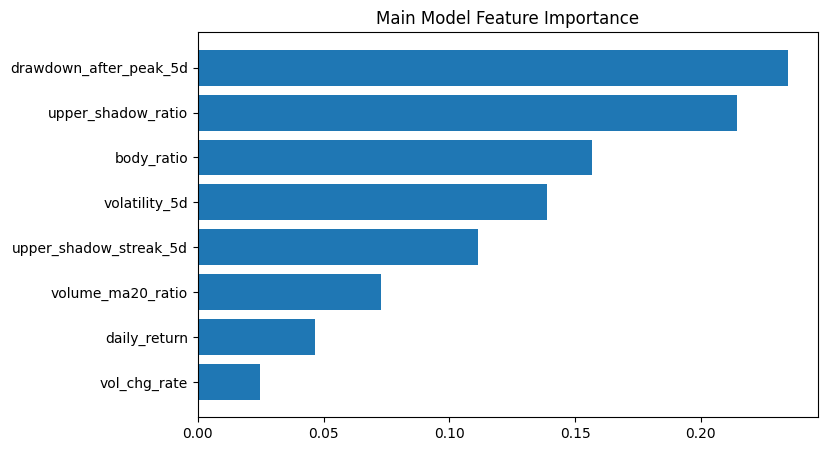

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Main Model Feature Importance"
)

plt.show()

## Main_Model version 2 : Isolation Forest + KMmeans


In [ ]:
# ============================================================
# Main Model V2
# Isolation Forest + KMeans
# Step 1. IF 97% Anomaly Extraction
# ============================================================

main_v2_train = train_df.copy()
main_v2_valid = valid_df.copy()
main_v2_test  = test_df.copy()

main_v2_features = common_cluster_features

# 기존에 학습한 main_scaler, main_iforest 사용 가능
# IF score 계산
main_v2_train["if_score"] = -main_iforest.decision_function(
    X_main_train_scaled
)

main_v2_valid["if_score"] = -main_iforest.decision_function(
    X_main_valid_scaled
)

main_v2_test["if_score"] = -main_iforest.decision_function(
    X_main_test_scaled
)

# Train 기준 97% threshold
main_v2_threshold = main_v2_train["if_score"].quantile(0.97)

print("Main V2 IF Threshold:", main_v2_threshold)

# 동일 threshold 적용
main_v2_train["if_anomaly"] = (
    main_v2_train["if_score"] >= main_v2_threshold
).astype(int)

main_v2_valid["if_anomaly"] = (
    main_v2_valid["if_score"] >= main_v2_threshold
).astype(int)

main_v2_test["if_anomaly"] = (
    main_v2_test["if_score"] >= main_v2_threshold
).astype(int)

main_v2_anomaly_train = main_v2_train[
    main_v2_train["if_anomaly"] == 1
].copy()

main_v2_anomaly_valid = main_v2_valid[
    main_v2_valid["if_anomaly"] == 1
].copy()

main_v2_anomaly_test = main_v2_test[
    main_v2_test["if_anomaly"] == 1
].copy()

print("Train IF anomaly:", main_v2_anomaly_train.shape)
print("Valid IF anomaly:", main_v2_anomaly_valid.shape)
print("Test IF anomaly :", main_v2_anomaly_test.shape)

Main V2 IF Threshold: 0.07419706603321813
Train IF anomaly: (1272, 19)
Valid IF anomaly: (140, 19)
Test IF anomaly : (163, 19)


In [ ]:
# ============================================================
# Main Model V2
# Step 2. KMeans K Tuning
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_main_v2_train = main_scaler.transform(
    main_v2_anomaly_train[main_v2_features]
)

main_v2_k_results = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_main_v2_train)

    sil = silhouette_score(
        X_main_v2_train,
        labels
    )

    main_v2_k_results.append({
        "k": k,
        "silhouette": sil,
        "anomaly_count": len(main_v2_anomaly_train)
    })

main_v2_k_results = pd.DataFrame(main_v2_k_results)

display(
    main_v2_k_results.sort_values(
        "silhouette",
        ascending=False
    )
)

,k,silhouette,anomaly_count
1,3,0.468105,1272
0,2,0.459381,1272
5,7,0.426439,1272
6,8,0.413181,1272
4,6,0.400367,1272
3,5,0.371687,1272
2,4,0.353302,1272


In [ ]:
# ============================================================
# Main Model V2
# Step 3. Final KMeans Training
# ============================================================

main_v2_final_k = 2

main_v2_kmeans = KMeans(
    n_clusters=main_v2_final_k,
    random_state=42,
    n_init=10
)

main_v2_anomaly_train["cluster"] = main_v2_kmeans.fit_predict(
    X_main_v2_train
)

main_v2_train_silhouette = silhouette_score(
    X_main_v2_train,
    main_v2_anomaly_train["cluster"]
)

print("Train Silhouette:", round(main_v2_train_silhouette, 4))

print("\n[Train Cluster Count]")
print(
    main_v2_anomaly_train["cluster"]
    .value_counts()
    .sort_index()
)

main_v2_train_profile = (
    main_v2_anomaly_train
    .groupby("cluster")[main_v2_features]
    .mean()
    .round(3)
)

display(main_v2_train_profile)

Train Silhouette: 0.4594

[Train Cluster Count]
cluster
0    1083
1     189
Name: count, dtype: int64


,volume_ma20_ratio,vol_chg_rate,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,4.164,10.463,0.031,0.056,0.144,0.140,3.597,1.825
1,0.736,0.131,0.000,0.000,-0.339,-13.255,13.749,0.000


In [ ]:
# ============================================================
# Main Model V2
# Step 4. Validation Evaluation
# ============================================================

X_main_v2_valid = main_scaler.transform(
    main_v2_anomaly_valid[main_v2_features]
)

main_v2_anomaly_valid["cluster"] = main_v2_kmeans.predict(
    X_main_v2_valid
)

main_v2_valid_silhouette = silhouette_score(
    X_main_v2_valid,
    main_v2_anomaly_valid["cluster"]
)

print("Validation Silhouette:", round(main_v2_valid_silhouette, 4))

print("\n[Validation Cluster Count]")
print(
    main_v2_anomaly_valid["cluster"]
    .value_counts()
    .sort_index()
)

main_v2_valid_profile = (
    main_v2_anomaly_valid
    .groupby("cluster")[main_v2_features]
    .mean()
    .round(3)
)

display(main_v2_valid_profile)

Validation Silhouette: 0.3388

[Validation Cluster Count]
cluster
0    132
1      8
Name: count, dtype: int64


,volume_ma20_ratio,vol_chg_rate,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,4.142,5.769,0.043,0.092,0.112,-0.157,0.978,1.0
1,0.518,-0.183,0.000,0.000,-0.312,-6.146,6.671,0.0


In [ ]:
# ============================================================
# Main Model V2
# Step 5. Test Evaluation
# ============================================================

X_main_v2_test = main_scaler.transform(
    main_v2_anomaly_test[main_v2_features]
)

main_v2_anomaly_test["cluster"] = main_v2_kmeans.predict(
    X_main_v2_test
)

main_v2_test_silhouette = silhouette_score(
    X_main_v2_test,
    main_v2_anomaly_test["cluster"]
)

print("Test Silhouette:", round(main_v2_test_silhouette, 4))

print("\n[Test Cluster Count]")
print(
    main_v2_anomaly_test["cluster"]
    .value_counts()
    .sort_index()
)

main_v2_test_profile = (
    main_v2_anomaly_test
    .groupby("cluster")[main_v2_features]
    .mean()
    .round(3)
)

display(main_v2_test_profile)

Test Silhouette: 0.3957

[Test Cluster Count]
cluster
0    162
1      1
Name: count, dtype: int64


,volume_ma20_ratio,vol_chg_rate,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,3.032,3.675,0.048,0.106,0.143,0.036,0.901,1.451
1,0.379,-0.403,0.000,0.000,-0.192,-10.370,10.656,0.000


In [ ]:
# ============================================================
# Main Model V2
# Final Summary
# ============================================================

main_v2_summary = pd.DataFrame({
    "Dataset": ["Train", "Valid", "Test"],
    "Silhouette": [
        main_v2_train_silhouette,
        main_v2_valid_silhouette,
        main_v2_test_silhouette
    ],
    "Anomaly Count": [
        len(main_v2_anomaly_train),
        len(main_v2_anomaly_valid),
        len(main_v2_anomaly_test)
    ]
})

display(main_v2_summary)

,Dataset,Silhouette,Anomaly Count
0,Train,0.459381,1272
1,Valid,0.338811,140
2,Test,0.395653,163
